2026/08/23, M. Ohno  

## 本ノートブックの内容  
分子の形状を表現する指標として、長軸、短軸、高さを数値で表現する手段を提供する。  
3D構造に、長軸、短軸、高さの軸を重ね書きして可視化する方法も記載している。  

In [ ]:
# pip installせず、colneして使う場合は、以下のpath付与をおこなう。  

#import os
#import sys

#sys.path.append(os.path.abspath(os.path.join("..", "src")))

### 基本的な使い方  
- molaspect.get_aspect_ratio("パスとファイル名") は、分子ごとに dict を返す。キーは name, var_ratio（分散比 1.0, PC2/PC1, PC3/PC1）, length_ratio（長さ比 1.0, L2/L1, L3/L1）, variance（三軸の分散）, length（三軸の長さ）, centroid（重心座標）, axes（三軸の固有ベクトル）。複数分子ならこの dict が並ぶ。  
- 対象となる3Dのファイル形式は.xyz, .mol, .pdbおよび .sdf, .mol2。sdfとmol2は複数分子を含んでよい。  
- 与える3D構造（座標）は構造最適化などをおこない、妥当な空間配置としておくこと。  
- 一つまたは複数のSMILESを記述した.csvファイルも読み込み対象。.csvファイルでは、一行目をヘッダとし、SMILESを記述した列の列名は"SMILES"（大文字であること）とする。  


In [2]:
import molaspect

molaspect.get_aspect_ratio("./sample_data/10364_phenylacetylene.mol")

[{'name': '10364_phenylacetylene.mol',
  'var_ratio': [1.0, 0.23344986882515864, 0.0],
  'length_ratio': [1.0, 0.4338208743199625, 0.0],
  'variance': [3.251093958609954, 0.7589674581757595, 0.0],
  'length': [5.317713104948629, 2.306934948571537, 0.0],
  'centroid': [2.7348125, -1.7474125, 0.0],
  'axes': [[-0.8660635005117279, -0.49993400872652416, -0.0],
   [0.49993400872652416, -0.8660635005117279, 0.0],
   [0.0, 0.0, 1.0]]}]

### アスペクト比の可視化  
- molaspect.view_aspect3d() 関数を用いる。指定した一分子ずつ可視化する思想で設計している。  
- 座標の原点は、重原子の幾何学的な重心。幾何的な特徴を捉えるために、原子量による重みづけはおこなっていない。 ±L/2。PC1=青, PC2=緑, PC3=マゼンタ。  

In [3]:
molaspect.view_aspect3d("./sample_data/10364_phenylacetylene.mol") 
# Structure2D_COMPOUND_CID_94932.sdf, Conformer3D_COMPOUND_CID_94932.sdf

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

複数ファイルの同時読み込みも可能

In [4]:
from pathlib import Path
import molaspect

sample_dir = Path("./sample_data")
exts = {".xyz", ".mol", ".pdb", ".sdf", ".mol2"}
paths = sorted(
    p for p in sample_dir.glob("*") if p.suffix.lower() in exts
)
for path in paths:
    print(path.name)
    print(molaspect.get_aspect_ratio(path))


10364_phenylacetylene.mol
[{'name': '10364_phenylacetylene.mol', 'var_ratio': [1.0, 0.23344986882515864, 0.0], 'length_ratio': [1.0, 0.4338208743199625, 0.0], 'variance': [3.251093958609954, 0.7589674581757595, 0.0], 'length': [5.317713104948629, 2.306934948571537, 0.0], 'centroid': [2.7348125, -1.7474125, 0.0], 'axes': [[-0.8660635005117279, -0.49993400872652416, -0.0], [0.49993400872652416, -0.8660635005117279, 0.0], [0.0, 0.0, 1.0]]}]
9130309_Adamantanyl_methacrylate.mol
[{'name': '9130309_Adamantanyl_methacrylate.mol', 'var_ratio': [1.0, 0.26217198658067864, 0.0], 'length_ratio': [1.0, 0.5203506088157803, 0.0], 'variance': [4.5593551186764705, 1.1953351889901962, 0.0], 'length': [6.484778430435811, 3.374358404312715, 0.0], 'centroid': [2.9458874999999995, -2.8006374999999997, 0.0], 'axes': [[-0.889806398657882, -0.4563382220540925, -0.0], [0.4563382220540925, -0.889806398657882, 0.0], [0.0, 0.0, 1.0]]}]
Conformer3D_COMPOUND_CID_10955092.sdf
[{'name': 'Conformer3D_COMPOUND_CID_10955

複数ファイルの計算結果をpandas.DataFrameにする場合  
- pandasはmol-aspectの依存パッケージとはしていないので、この例を動かす場合には別途installしてください。  

In [5]:
from pathlib import Path
import pandas as pd
import molaspect

sample_dir = Path("./sample_data")
exts = {".xyz", ".mol", ".pdb", ".sdf", ".mol2"}
paths = sorted(
    p for p in sample_dir.glob("*") if p.suffix.lower() in exts
)
records = []
for path in paths:
    records.extend(molaspect.get_aspect_ratio(path))
df = pd.DataFrame(records)
df


,name,var_ratio,length_ratio,variance,length,centroid,axes
0,10364_phenylacetylene.mol,"[1.0, 0.23344986882515864, 0.0]","[1.0, 0.4338208743199625, 0.0]","[3.251093958609954, 0.7589674581757595, 0.0]","[5.317713104948629, 2.306934948571537, 0.0]","[2.7348125, -1.7474125, 0.0]","[[-0.8660635005117279, -0.49993400872652416, -..."
1,9130309_Adamantanyl_methacrylate.mol,"[1.0, 0.26217198658067864, 0.0]","[1.0, 0.5203506088157803, 0.0]","[4.5593551186764705, 1.1953351889901962, 0.0]","[6.484778430435811, 3.374358404312715, 0.0]","[2.9458874999999995, -2.8006374999999997, 0.0]","[[-0.889806398657882, -0.4563382220540925, -0...."
2,Conformer3D_COMPOUND_CID_10955092.sdf_1,"[1.0, 0.16945459848647554, 0.1023445227035422]","[1.0, 0.4493319313741284, 0.3459687477991174]","[6.1733926402126205, 1.0461097711465928, 0.631...","[7.29458930198332, 3.2776918996412205, 2.52369...","[0.0, 6.2500000000062506e-06, -6.2500000000125...","[[-0.9999999999795081, -5.915025561901679e-06,..."
3,Conformer3D_COMPOUND_CID_94932.sdf_1,"[1.0, 0.15695942552806808, 0.0578347215978852]","[1.0, 0.3469330308797614, 0.24099388929540566]","[9.071244540482558, 1.4238173318987661, 0.5246...","[10.143400213100993, 3.5190805793575453, 2.444...","[-7.836868409118753e-17, 5.8823529412019454e-0...","[[-0.99999999996968, 6.301313040279524e-06, -4..."
4,Structure2D_COMPOUND_CID_94932.sdf_1,"[1.0, 0.09301916279069768, 0.0]","[1.0, 0.25, 0.0]","[5.375, 0.49997800000000003, 0.0]","[8.0, 2.0, 0.0]","[3.0, 0.0, 0.0]","[[0.0, 1.0, 0.0], [1.0, 0.0, 0.0], [0.0, 0.0, ..."


### SMILESを読む  

simplified molecular input line entry system (SMILES: https://doi.org/10.1021/ci00057a005) で記述した分子を直接読み込む場合には、read_smiles関数を使用する。  
複数のSMILESを与える場合には、.csvファイルとし、一行目をヘッダにする。またSMILESを記述した列の列名は"SMILES"（大文字であること）とする。

In [6]:
from molaspect import read_smiles, extract_heavy_atoms, mol_aspect_ratio

for name, mol in read_smiles("CC(=C)C(=O)OC12CC3CC(C1)CC(C3)C2",optimize=True):
    aspect = mol_aspect_ratio(extract_heavy_atoms(mol))
aspect

{'var_ratio': [1.0, 0.15513359536918053, 0.09519869878381598],
 'length_ratio': [1.0, 0.42582012825118803, 0.33744569806646496],
 'variance': [6.728405152506932, 1.0438016824089198, 0.6405354154089828],
 'length': [7.56792260299245, 3.22257377340131, 2.553762925679766],
 'centroid': [0.1941706985154614, 0.11197225327709681, -0.0025412425954584074],
 'axes': [[-0.9990776114913068, -0.034328606661374654, -0.025796763004571694],
  [0.025768693490576724, -0.9598529401071433, 0.2793175751782573],
  [-0.03434968198708866, 0.2783951869777229, 0.9598521861281688]]}

In [7]:
# SMILES は先に 3D mol を作り、mol= で渡す。
from molaspect import read_smiles, view_aspect3d

for name, mol in read_smiles("CC(=C)C(=O)OC12CC3CC(C1)CC(C3)C2",optimize=True):
    view = view_aspect3d(mol=mol)
view

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

SMILESを集めた.csvから計算する。SMILESの列名が "SMILES"である必要がある。  
この例では、optimizeしていない。  

In [8]:
import molaspect

molaspect.get_aspect_ratio("./sample_data/SMILESs.csv")

[{'name': 'SMILESs.csv_2',
  'var_ratio': [1.0, 0.12096846876143771, 0.023509679238436477],
  'length_ratio': [1.0, 0.33823534451553877, 0.13543470560791443],
  'variance': [2.9573027547741084, 0.3577403859090054, 0.06952523917568386],
  'length': [4.206994398318471, 1.42295419969019, 0.5697730478304073],
  'centroid': [0.26795522470919114, 0.051075819743404506, 0.17410992339664869],
  'axes': [[-0.9956591607130815, 0.03222876145429095, -0.08731633651983084],
   [-0.03848456765576005, 0.7116292452350244, 0.7015003602127218],
   [0.08474534642368962, 0.7018155913495738, -0.7072998670989394]]},
 {'name': 'SMILESs.csv_3',
  'var_ratio': [1.0, 0.33252355016947244, 0.031151533071693997],
  'length_ratio': [1.0, 0.5498270285390029, 0.17160274745160692],
  'variance': [2.01184263746322, 0.6689850561915848, 0.06267198245597957],
  'length': [3.7219583042400695, 2.0464332747663834, 0.6386982709079198],
  'centroid': [-0.03674068820620209, 0.1919796744832513, -0.07277719525181633],
  'axes': [[-

SMILESから立体構造を発生させ、optimizeしてaspect比を計算するには、例えば以下の様におこなう。
- pandasが必要    

In [9]:
import pandas as pd
from molaspect import read_smiles, extract_heavy_atoms, mol_aspect_ratio

df = pd.read_csv("./sample_data/SMILESs.csv")

def aspect_from_smiles(smi, optimize=True):
    _, mol = next(read_smiles(smi, optimize=optimize))
    return mol_aspect_ratio(extract_heavy_atoms(mol))

df_rsl = pd.DataFrame(df["SMILES"].apply(aspect_from_smiles, optimize=True).tolist())
df_rsl

,var_ratio,length_ratio,variance,length,centroid,axes
0,"[1.0, 0.11331237342191278, 0.023309774936414722]","[1.0, 0.32662807644956043, 0.13175168693919312]","[3.114229381664275, 0.3528807226166349, 0.0725...","[4.338014372357799, 1.4169172900537752, 0.5715...","[0.2885807644917829, 0.023903761795849177, 0.1...","[[-0.9924471648843632, 0.012512754397705828, -..."
1,"[1.0, 0.3317262000918091, 0.027815332891764993]","[1.0, 0.5429616835617225, 0.1623202359984279]","[2.101734162909697, 0.6972002874651729, 0.0584...","[3.814274670793666, 2.071004996820964, 0.61913...","[-0.0470054035699496, 0.16219702028687427, -0....","[[-0.9965996223452432, 0.07446519085981253, 0...."
2,"[1.0, 0.9857149402341242, 0.8615484671971134]","[1.0, 0.8551279423806046, 0.8095462060706596]","[0.7971627977802594, 0.7857752795708357, 0.686...","[2.525332132207164, 2.1594820700419373, 2.0443...","[0.10764092773252062, -0.1932411864693518, 0.1...","[[0.4467713285576519, 0.6581395024441741, 0.60..."
3,"[1.0, 0.2558924847842073, 0.037050343273145624]","[1.0, 0.49615485883447263, 0.17666711206675015]","[4.925688508875232, 1.2604466718090999, 0.1824...","[6.938672076072897, 3.4426558644026453, 1.2258...","[-0.09240541023945567, 0.12408765979275826, 0....","[[-0.9940495468597417, -0.10817745722301317, 0..."


### 参考  
未成型座標の3Dファイルや、2Dの配座ファイルから構造発生＋最適化させる一例を記す。

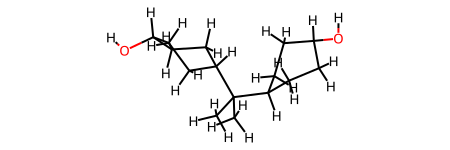

In [10]:
from rdkit import Chem
from rdkit.Chem import AllChem

suppl = Chem.SDMolSupplier("./sample_data/Structure2D_COMPOUND_CID_94932.sdf", removeHs=False)
mol_0 = suppl[0] # 今回は位置化合物だが、最初の化合物を取り出している  
target_mol = Chem.AddHs(mol_0) # 水素の欠損がある場会に備えて
status_3D = AllChem.EmbedMolecule(target_mol) # 立体配座を生成, status_3D = 0で成功
status_optimize = AllChem.UFFOptimizeMolecule(target_mol)

# mol-aspectで使用するために.molファイルで出力する場合（コメントアウトを解除して使用）
# Chem.MolToMolFile(target_mol, "./sample_data/target_mol.mol")

# 立体配座生成、構造最適化した分子を表示しておく
target_mol

### reference  
1. sample_dataの3DファイルやSMILESは、PubChem (https://pubchem.ncbi.nlm.nih.gov/), ChemSpider (https://www.chemspider.com/) から取得した。  